In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_excel(r"C:\Users\YASH\Downloads\Online Retail.xlsx")
print("Shape of dataset:", df.shape)
df.head(2)

Shape of dataset: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 541909
Number of columns: 8


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df = df.dropna(subset=['CustomerID'])

In [6]:
df = df.drop_duplicates()

In [7]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [9]:
df = df[df['Quantity'] > 0]

In [10]:
df = df[df['UnitPrice'] > 0]

In [11]:
# Calculate total amount spent per transaction
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
display(df.head())
print("Total Revenue:", round(df['TotalAmount'].sum(), 2))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


Total Revenue: 8887208.89


In [12]:
# Descriptive statistics

print("Average Purchase Value:")
print(round(df['TotalAmount'].mean(), 2))

print("\nAverage Quantity Purchased:")
print(round(df['Quantity'].mean(), 2))

print("\nTotal Customers:")
print(df['CustomerID'].nunique())

print("\nTotal Transactions:")
print(df['InvoiceNo'].nunique())

print("\nDescriptive Statistics:")
display(df[['Quantity', 'UnitPrice', 'TotalAmount']].describe())

Average Purchase Value:
22.63

Average Quantity Purchased:
13.12

Total Customers:
4338

Total Transactions:
18532

Descriptive Statistics:


,Quantity,UnitPrice,TotalAmount
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [13]:
# Create reference date
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']
print("RFM table created successfully!")
display(rfm.head())

RFM table created successfully!


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [14]:
# RFM descriptive statistics
display(rfm.describe())

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


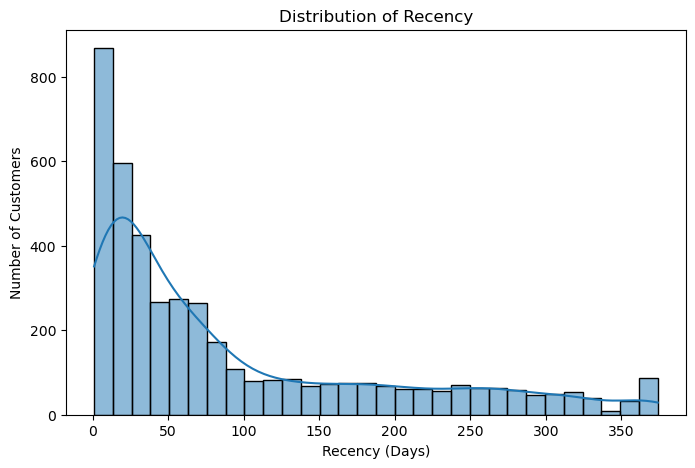

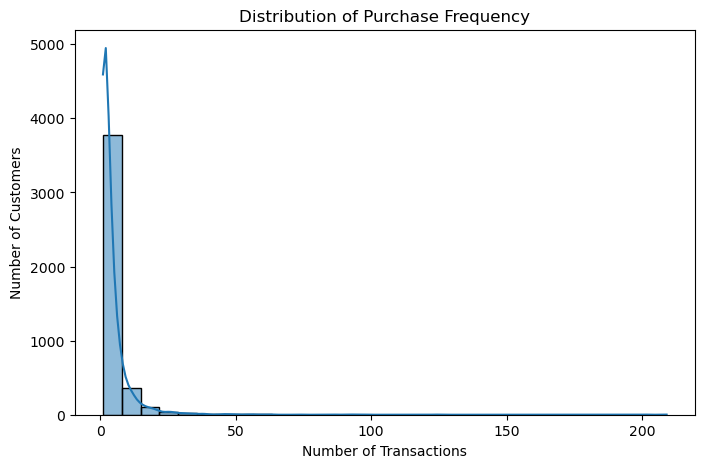

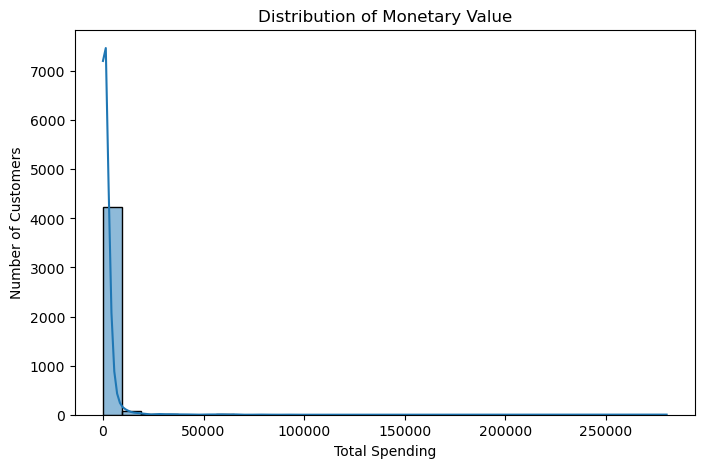

In [15]:
# Visualize RFM distributions

plt.figure(figsize=(8, 5))
sns.histplot(rfm['Recency'], bins=30, kde=True)
plt.title('Distribution of Recency')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')
plt.show()


plt.figure(figsize=(8, 5))
sns.histplot(rfm['Frequency'], bins=30, kde=True)
plt.title('Distribution of Purchase Frequency')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Customers')
plt.show()


plt.figure(figsize=(8, 5))
sns.histplot(rfm['Monetary'], bins=30, kde=True)
plt.title('Distribution of Monetary Value')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')
plt.show()

In [16]:
# Log transformation to reduce skewness
rfm_log = np.log1p(rfm)
print("Log transformation completed.")
display(rfm_log.head())

Log transformation completed.


,Recency,Frequency,Monetary
CustomerID,,,
12346,5.789960,0.693147,11.253955
12347,1.098612,2.079442,8.368925
12348,4.330733,1.609438,7.494564
12349,2.995732,0.693147,7.472245
12350,5.739793,0.693147,5.815324


In [17]:
# Standardize RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)
print("RFM data standardized successfully!")
display(rfm_scaled.head())

RFM data standardized successfully!


,Recency,Frequency,Monetary
CustomerID,,,
12346,1.461993,-0.955214,3.707716
12347,-2.038734,1.074425,1.414903
12348,0.373104,0.386304,0.720024
12349,-0.623086,-0.955214,0.702287
12350,1.424558,-0.955214,-0.614514


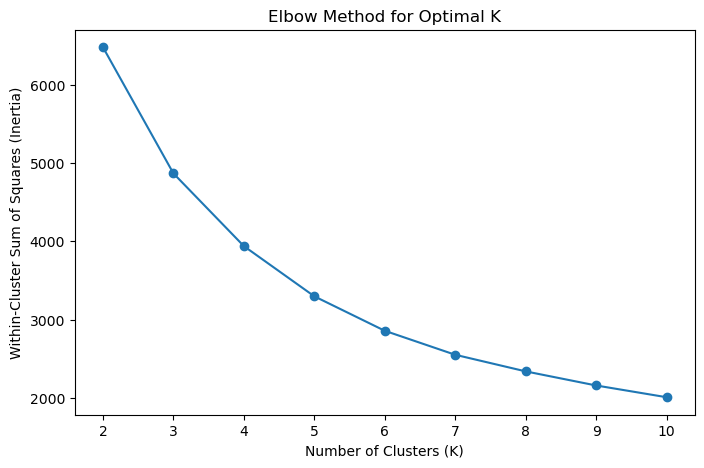

In [18]:
# Elbow Method to find optimal number of clusters
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (Inertia)')
plt.xticks(K_range)
plt.show()

In [19]:
# Apply K-Means clustering
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
print("K-Means clustering completed!")
display(rfm.head())

K-Means clustering completed!


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,3
12347,2,7,4310.00,0
12348,75,4,1797.24,3
12349,19,1,1757.55,2
12350,310,1,334.40,1


Customers in each cluster:
Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64


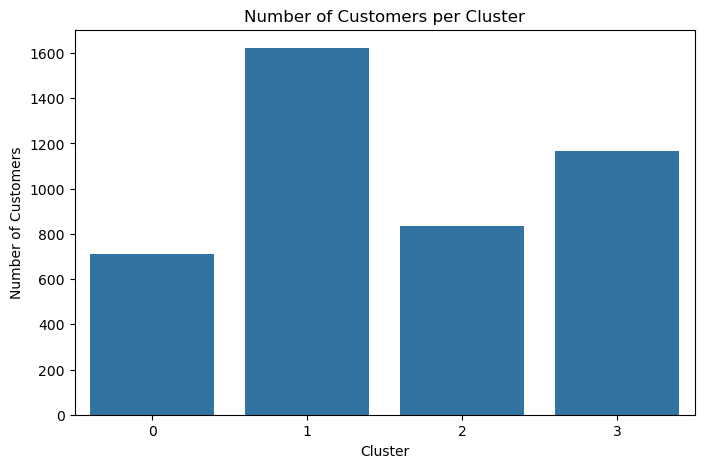

In [20]:
# Count customers in each cluster
cluster_counts = rfm['Cluster'].value_counts().sort_index()
print("Customers in each cluster:")
print(cluster_counts)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

In [21]:
# Calculate average RFM values for each cluster
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

cluster_profile['Customer_Count'] = rfm.groupby('Cluster').size()
display(cluster_profile)

,Recency,Frequency,Monetary,Customer_Count
Cluster,,,,
0,12.17,13.75,8088.02,713
1,181.51,1.32,341.00,1622
2,17.70,2.19,557.32,837
3,71.64,4.08,1801.78,1166


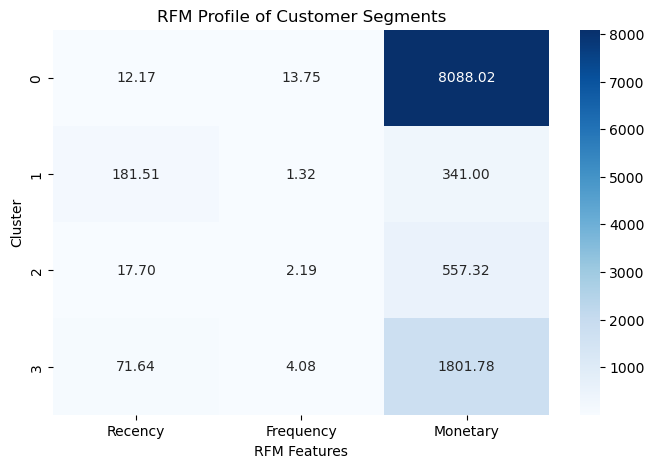

In [22]:
# Heatmap of average RFM values by cluster
plt.figure(figsize=(8, 5))
sns.heatmap(
    cluster_profile[['Recency', 'Frequency', 'Monetary']],
    annot=True,
    fmt='.2f',
    cmap='Blues'
)
plt.title('RFM Profile of Customer Segments')
plt.xlabel('RFM Features')
plt.ylabel('Cluster')
plt.show()

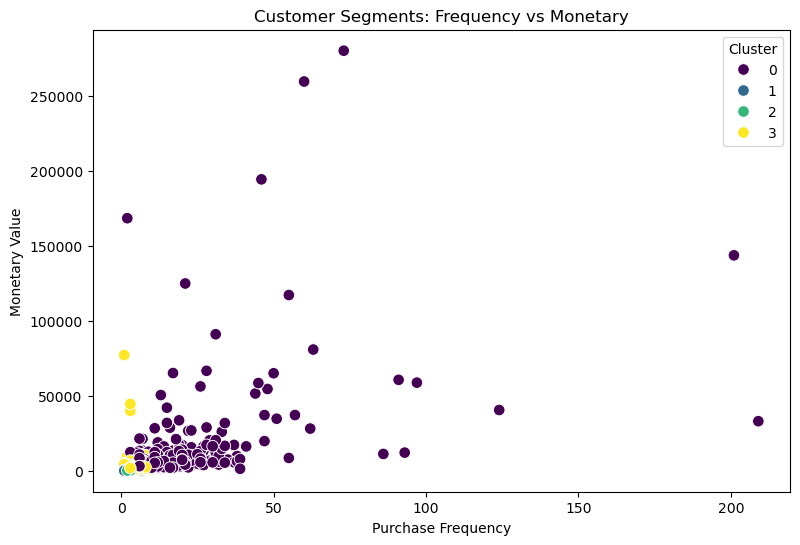

In [23]:
# Cluster visualization: Frequency vs Monetary

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=70
)
plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')
plt.show()

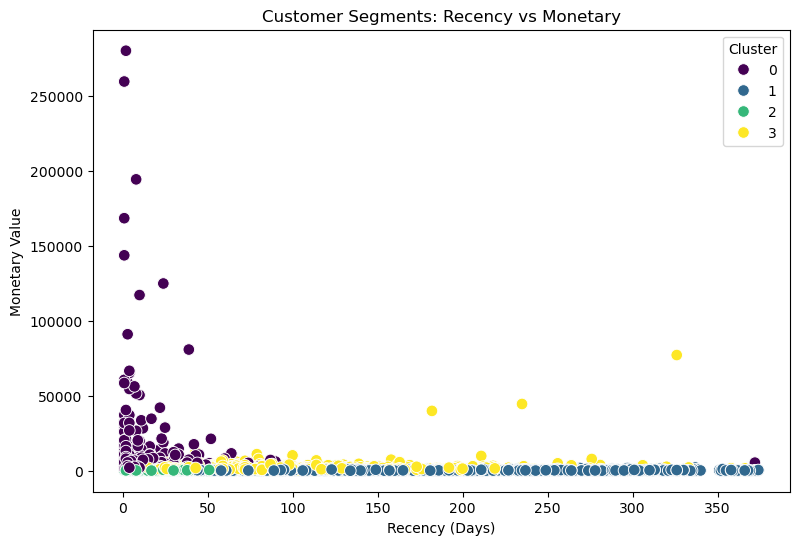

In [24]:
# Cluster visualization: Recency vs Monetary

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=70
)
plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.legend(title='Cluster')
plt.show()

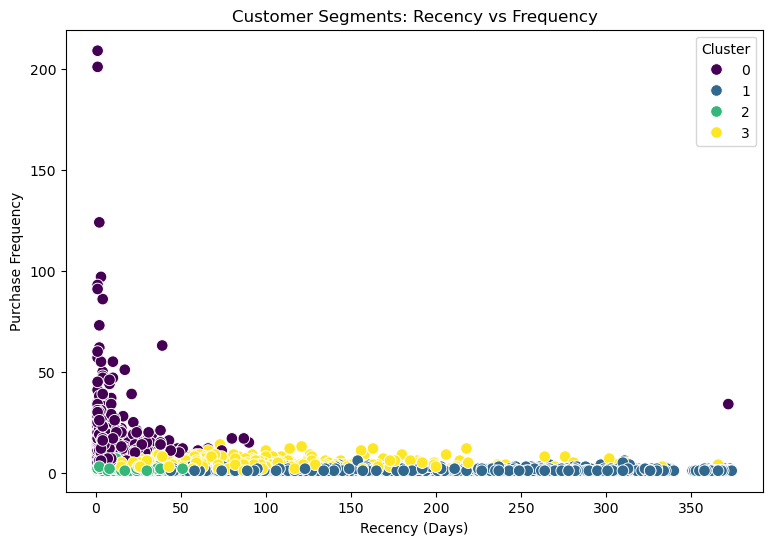

In [25]:
# Cluster visualization: Recency vs Frequency
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    hue='Cluster',
    palette='viridis',
    s=70
)
plt.title('Customer Segments: Recency vs Frequency')
plt.xlabel('Recency (Days)')
plt.ylabel('Purchase Frequency')
plt.legend(title='Cluster')
plt.show()

In [26]:
# Rank clusters based on RFM characteristics
cluster_profile['Recency_Rank'] = cluster_profile['Recency'].rank(
    ascending=True
)
cluster_profile['Frequency_Rank'] = cluster_profile['Frequency'].rank(
    ascending=False
)
cluster_profile['Monetary_Rank'] = cluster_profile['Monetary'].rank(
    ascending=False
)
cluster_profile['Overall_Score'] = (
    cluster_profile['Recency_Rank'] +
    cluster_profile['Frequency_Rank'] +
    cluster_profile['Monetary_Rank']
)
display(cluster_profile.sort_values('Overall_Score'))

,Recency,Frequency,Monetary,Customer_Count,Recency_Rank,Frequency_Rank,Monetary_Rank,Overall_Score
Cluster,,,,,,,,
0,12.17,13.75,8088.02,713,1.0,1.0,1.0,3.0
3,71.64,4.08,1801.78,1166,3.0,2.0,2.0,7.0
2,17.70,2.19,557.32,837,2.0,3.0,3.0,8.0
1,181.51,1.32,341.00,1622,4.0,4.0,4.0,12.0


In [27]:
# Create meaningful customer segment labels
profile = cluster_profile.copy()

# Sort clusters based on RFM characteristics
# Lower Recency = more recent
# Higher Frequency = more loyal
# Higher Monetary = higher customer value

profile['Score'] = (
    profile['Recency'].rank(ascending=True) +
    profile['Frequency'].rank(ascending=False) +
    profile['Monetary'].rank(ascending=False)
)

# Identify important clusters
champion_cluster = profile['Score'].idxmin()

# Highest frequency among remaining clusters
remaining = profile.drop(index=champion_cluster)
loyal_cluster = remaining['Frequency'].idxmax()

# Highest recency (least recent) among remaining clusters
remaining2 = remaining.drop(index=loyal_cluster)
at_risk_cluster = remaining2['Recency'].idxmax()

# Remaining cluster = potential customers
potential_cluster = [
    c for c in profile.index
    if c not in [champion_cluster, loyal_cluster, at_risk_cluster]
][0]

segment_names = {
    champion_cluster: 'Champions',
    loyal_cluster: 'Loyal Customers',
    potential_cluster: 'Potential Customers',
    at_risk_cluster: 'At Risk'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

print("Customer segment labels created successfully!")

display(
    rfm[['Cluster', 'Segment']].head(10)
)

Customer segment labels created successfully!


,Cluster,Segment
CustomerID,,
12346,3,Loyal Customers
12347,0,Champions
12348,3,Loyal Customers
12349,2,Potential Customers
12350,1,At Risk
12352,3,Loyal Customers
12353,1,At Risk
12354,1,At Risk
12355,1,At Risk


In [28]:
# Final customer segment profile
final_profile = rfm.groupby(['Cluster', 'Segment']).agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

final_profile['Customer_Count'] = rfm.groupby(
    ['Cluster', 'Segment']
).size()

display(final_profile)

,,Recency,Frequency,Monetary,Customer_Count
Cluster,Segment,,,,
0,Champions,12.17,13.75,8088.02,713
1,At Risk,181.51,1.32,341.00,1622
2,Potential Customers,17.70,2.19,557.32,837
3,Loyal Customers,71.64,4.08,1801.78,1166


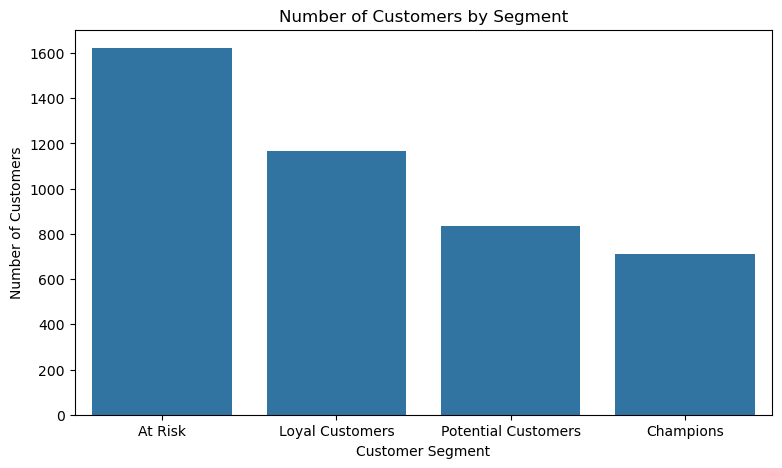

In [29]:
# Customer count by segment
segment_counts = rfm['Segment'].value_counts()
plt.figure(figsize=(9, 5))
sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)
plt.title('Number of Customers by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.show()

In [30]:
# Display segment profiles for business interpretation
for segment in final_profile.index:
    
    cluster = segment[0]
    segment_name = segment[1]
    
    data = final_profile.loc[segment]
    
    print("=" * 60)
    print(f"SEGMENT: {segment_name}")
    print(f"Cluster: {cluster}")
    print(f"Customers: {int(data['Customer_Count'])}")
    print(f"Average Recency: {data['Recency']:.2f} days")
    print(f"Average Frequency: {data['Frequency']:.2f} purchases")
    print(f"Average Monetary Value: {data['Monetary']:.2f}")
    print("=" * 60)

SEGMENT: Champions
Cluster: 0
Customers: 713
Average Recency: 12.17 days
Average Frequency: 13.75 purchases
Average Monetary Value: 8088.02
SEGMENT: At Risk
Cluster: 1
Customers: 1622
Average Recency: 181.51 days
Average Frequency: 1.32 purchases
Average Monetary Value: 341.00
SEGMENT: Potential Customers
Cluster: 2
Customers: 837
Average Recency: 17.70 days
Average Frequency: 2.19 purchases
Average Monetary Value: 557.32
SEGMENT: Loyal Customers
Cluster: 3
Customers: 1166
Average Recency: 71.64 days
Average Frequency: 4.08 purchases
Average Monetary Value: 1801.78


## Marketing Recommendations

### 1. Champions
These customers purchase frequently, recently, and generate high monetary value.

**Recommended Action:**
- Provide loyalty rewards and exclusive offers.
- Give early access to new products.
- Introduce referral programs to retain these high-value customers.

### 2. Loyal Customers
These customers purchase regularly and have strong engagement with the business.

**Recommended Action:**
- Introduce loyalty points and membership benefits.
- Provide personalised product recommendations.
- Encourage repeat purchases through targeted promotions.

### 3. Potential Customers
These customers show purchasing activity but have room for increased engagement.

**Recommended Action:**
- Use personalised offers to increase purchase frequency.
- Provide cross-selling and upselling recommendations.
- Send targeted promotional campaigns.

### 4. At Risk
These customers have not purchased recently and may be losing interest.

**Recommended Action:**
- Launch win-back campaigns.
- Offer limited-time discounts.
- Send personalised reminders and product recommendations.

## Conclusion

K-Means clustering successfully divided the e-commerce customer base into distinct groups based on Recency, Frequency and Monetary behaviour. These segments can help the company develop targeted marketing strategies instead of using the same strategy for every customer.